# Pipeline Completo: Processamento de Dados Experimentais

Este notebook demonstra o pipeline completo para processar dados experimentais de ultrassom, desde a leitura e escalonamento até a predição de altura usando autoencoder e KNN.

## Etapas do Pipeline:
1. **Leitura e Escalonamento dos Dados Reais**: Ler o dataset experimental e dividir por 500.000 para compatibilizar com o domínio dos dados artificiais.
2. **Denoising com Autoencoder**: Aplicar o autoencoder treinado (dae_best.pt) para remover ruído e gerar dados limpos.
3. **Predição com KNN**: Usar o KNN treinado (knn_checkpoint_synthetic.joblib) para estimar alturas a partir dos dados limpos.
4. **Avaliação de Desempenho**: Comparar métricas do KNN usando dados tratados pelo autoencoder vs. dados reais apenas escalados.

## Dependências:
- numpy, h5py, torch, scikit-learn, joblib

In [1]:
# Imports necessários
import h5py
import numpy as np
import torch
from pathlib import Path
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Arquivos
EXPERIMENTAL_FILE = 'model_compound_4_10_104_1_interface_realisticfull_apod.h5'
DAE_MODEL_PATH = 'dae_best_262_matrizerror_bigger_N_100.pt'
KNN_MODEL_PATH = 'knn_checkpoint_synthetic.joblib'
DATA_DIR = Path('.')

# Fator de escala
SCALE_FACTOR = 500000

## Etapa 1: Leitura e Escalonamento dos Dados Reais

Lemos o dataset experimental, extraímos os valores de 16 medidas para cada altura, e dividimos por 500.000 para compatibilizar com os dados artificiais.

In [2]:
def load_experimental_data(fname):
    """Carrega dados experimentais e retorna lista de (altura, valores_16)."""
    file_path = DATA_DIR / fname
    data = []
    with h5py.File(file_path, 'r') as f:
        target = [None]
        def finder(name, obj):
            if isinstance(obj, h5py.Dataset) and name.endswith('N_compound_maxenv'):
                target[0] = name
        f.visititems(finder)
        if target[0] is None:
            raise ValueError(f"Dataset não encontrado em {fname}")
        
        d = f[target[0]]
        axis_H = np.asanyarray(d.attrs.get('axis_H', np.arange(d.shape[0])))
        
        for hi, hval in enumerate(axis_H):
            for ki in range(d.shape[2]):  # Geralmente 1
                vals = d[hi, 0, ki, 0, :]
                vals_scaled = np.asanyarray(vals).ravel() / SCALE_FACTOR
                data.append((float(hval), vals_scaled))
    return data

# Carregar dados experimentais escalados
experimental_data = load_experimental_data(EXPERIMENTAL_FILE)
print(f"Dados experimentais carregados: {len(experimental_data)} amostras")
print(f"Exemplo: Altura {experimental_data[0][0]:.2f}, Valores: {experimental_data[0][1][:4]}...")

# Preparar arrays para processamento
heights = np.array([h for h, _ in experimental_data])
features_scaled = np.array([v for _, v in experimental_data])
print(f"Shapes: heights {heights.shape}, features {features_scaled.shape}")

Dados experimentais carregados: 90 amostras
Exemplo: Altura 40.18, Valores: [1.57584148e-05 2.90392190e-06 1.00039448e-06 1.79869683e-06]...
Shapes: heights (90,), features (90, 16)


## Etapa 2: Denoising com Autoencoder

Carregamos o autoencoder treinado (dae_best.pt) e aplicamos aos dados escalados para gerar versões "limpas" (denoised).

C:\Users\mateu\AppData\Local\Temp\ipykernel_26196\291095912.py:57: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dae_model.load_state_dict(torch.load(DAE_MODEL_PATH, map_loc

Scaler carregado - mean (primeiras 4): [1.26311474e-05 6.79998688e-06 1.55465494e-06 1.43377276e-06]
Dados denoised gerados: shape (90, 16)
Exemplo denoised (após denormalizacao): [1.1122250e-05 4.8294369e-06 8.6948450e-07 4.5539417e-07]...

=== Verificações do Autoencoder ===
Saída para entrada zero (denormalizada): [1.04833825e-05 7.55194242e-06 1.93293022e-06 1.71533327e-06]...
Saída para primeira amostra (denormalizada): [1.1122248e-05 4.8294351e-06 8.6948427e-07 4.5539440e-07]...
Entrada original (antes de normalizar): [1.57584148e-05 2.90392190e-06 1.00039448e-06 1.79869683e-06]...
Diferença (saída - entrada): [-4.63616684e-06  1.92551316e-06 -1.30910215e-07 -1.34330243e-06]...
Modelo em eval mode: True
Parâmetros do encoder (primeira camada weights shape): torch.Size([48, 16])
Parâmetros do decoder (primeira camada weights shape): torch.Size([48, 12])
Média das saídas denoised: [1.40627635e-05 7.30990496e-06 1.58200010e-06 1.23871916e-06]...
Std das saídas denoised: [3.4387742e-

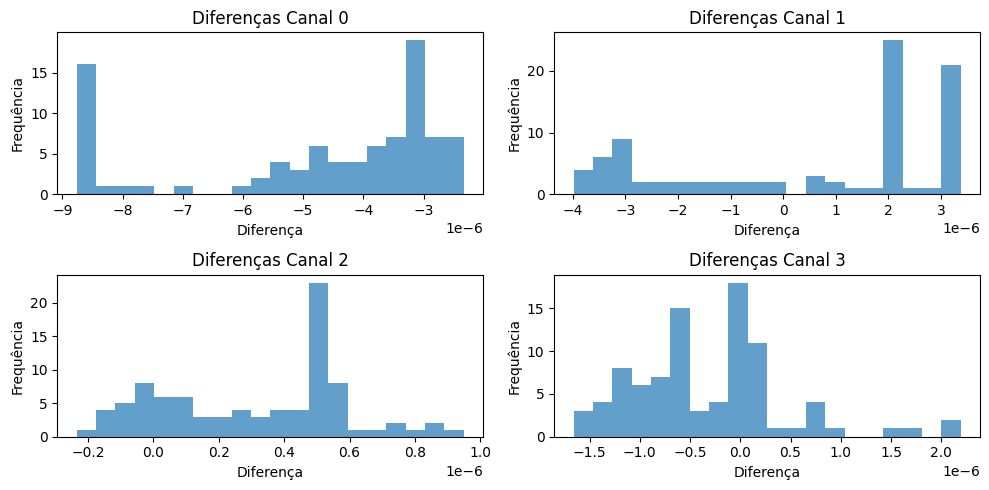

In [3]:
# Assumindo estrutura do autoencoder baseada em denoising_autoencoder.py
# (Ajuste conforme necessário; aqui um exemplo genérico)
import torch.nn as nn

class DenoisingAutoencoder(nn.Module):
    """
    Autoencoder denoising com conexão residual.

    Em vez de reconstruir o sinal completo, o modelo aprende a
    CORREÇÃO a aplicar sobre a entrada ruidosa:

        x̂ = x̃ + Decoder(Encoder(x̃))

    Isso é mais eficiente para ruídos pequenos (σ ≈ 0.002) porque
    o modelo só precisa estimar a perturbação, não o sinal inteiro.

    Parâmetros
    ----------
    input_dim  : dimensão das medições (16 canais)
    latent_dim : dimensão do espaço latente (espaço comprimido)
    """
    def __init__(self, input_dim: int = 16, latent_dim: int = 12):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 48),
            nn.BatchNorm1d(48),
            nn.GELU(),
            nn.Linear(48, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 48),
            nn.BatchNorm1d(48),
            nn.GELU(),
            nn.Linear(48, input_dim),
        )

        # Inicializa os pesos do decoder próximos de zero para que
        # no início do treino a saída ≈ entrada (perturbação ≈ 0)
        nn.init.zeros_(self.decoder[-1].weight)
        nn.init.zeros_(self.decoder[-1].bias)

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return self.encoder(x)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        return self.decoder(z)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Retorna x̃ + correção aprendida (conexão residual)."""
        correction = self.decode(self.encode(x))
        return x + correction

# Carregar modelo
dae_model = DenoisingAutoencoder()
dae_model.load_state_dict(torch.load(DAE_MODEL_PATH, map_location='cpu'))
dae_model.to('cpu')
dae_model.eval()

# Carregar scaler que foi usado no treinamento do KNN
checkpoint = joblib.load(KNN_MODEL_PATH)
scaler = checkpoint['scaler']
print(f"Scaler carregado - mean (primeiras 4): {scaler.mean_[:4]}")

# IMPORTANTE: Normalizar os dados com o scaler ANTES de passar para o autoencoder
# O autoencoder foi treinado com dados normalizados
features_scaled_normalized = scaler.transform(features_scaled)

# Processar dados com autoencoder (entrada normalizada)
features_tensor = torch.tensor(features_scaled_normalized, dtype=torch.float32)
with torch.no_grad():
    features_denoised_normalized = dae_model(features_tensor).numpy()

# IMPORTANTE: Desnormalizar as saídas do autoencoder
# As saídas estão no espaço normalizado, precisamos retornar ao espaço original
features_denoised = scaler.inverse_transform(features_denoised_normalized)

print(f"Dados denoised gerados: shape {features_denoised.shape}")
print(f"Exemplo denoised (após denormalizacao): {features_denoised[0][:4]}...")

# Verificações adicionais do autoencoder
print("\n=== Verificações do Autoencoder ===")

# 1. Teste com entrada simples (vetor de zeros normalizado)
test_input_zero = torch.zeros((1, 16), dtype=torch.float32)
with torch.no_grad():
    test_output_zero = dae_model(test_input_zero).numpy()
test_output_zero_denorm = scaler.inverse_transform(test_output_zero)
print(f"Saída para entrada zero (denormalizada): {test_output_zero_denorm[0][:4]}...")

# 2. Teste com entrada conhecida (ex.: primeira amostra normalizada)
test_input_sample = features_tensor[:1]
with torch.no_grad():
    test_output_sample = dae_model(test_input_sample).numpy()
test_output_sample_denorm = scaler.inverse_transform(test_output_sample)
print(f"Saída para primeira amostra (denormalizada): {test_output_sample_denorm[0][:4]}...")
print(f"Entrada original (antes de normalizar): {features_scaled[0][:4]}...")
print(f"Diferença (saída - entrada): {test_output_sample_denorm[0][:4] - features_scaled[0][:4]}...")

# 3. Verificar se o modelo está carregado corretamente
print(f"Modelo em eval mode: {not dae_model.training}")
print(f"Parâmetros do encoder (primeira camada weights shape): {dae_model.encoder[0].weight.shape}")
print(f"Parâmetros do decoder (primeira camada weights shape): {dae_model.decoder[0].weight.shape}")

# 4. Verificar estatísticas das saídas denoised (denormalizadas)
print(f"Média das saídas denoised: {np.mean(features_denoised, axis=0)[:4]}...")
print(f"Std das saídas denoised: {np.std(features_denoised, axis=0)[:4]}...")
print(f"Range das saídas denoised: {np.min(features_denoised)} a {np.max(features_denoised)}")

# 5. Plot simples das diferenças por canal
import matplotlib.pyplot as plt
differences = features_denoised - features_scaled
plt.figure(figsize=(10, 5))
for i in range(min(4, differences.shape[1])):  # Plotar primeiros 4 canais
    plt.subplot(2, 2, i+1)
    plt.hist(differences[:, i], bins=20, alpha=0.7)
    plt.title(f'Diferenças Canal {i}')
    plt.xlabel('Diferença')
    plt.ylabel('Frequência')
plt.tight_layout()
plt.show()


## Etapa 3: Predição com KNN

Usamos o KNN treinado (knn_checkpoint_synthetic.joblib) para predizer alturas a partir dos dados denoised.

In [4]:
# Carregar apenas o modelo KNN do checkpoint (scaler já foi carregado na Etapa 2)
checkpoint = joblib.load(KNN_MODEL_PATH)
knn_model = checkpoint['knn']
scaler = checkpoint['scaler']

print('Modelo KNN carregado:')
print(f'  n_neighbors: {knn_model.n_neighbors}')
print(f'  Scaler mean (primeiras 4): {scaler.mean_[:4]}')

# Os dados denoised já estão em escala original (denormalizados na Etapa 2)
# Precisamos normalizá-los novamente para o KNN usar
features_denoised_scaled = scaler.transform(features_denoised)

# Predizer alturas com dados denoised escalados
predicted_heights_denoised = knn_model.predict(features_denoised_scaled)

print(f"Alturas preditas (denoised): {predicted_heights_denoised[:5]}...")
print(f"Alturas reais: {heights[:5]}...")

# Métricas para denoised
mae_denoised = mean_absolute_error(heights, predicted_heights_denoised)
rmse_denoised = np.sqrt(mean_squared_error(heights, predicted_heights_denoised))
r2_denoised = r2_score(heights, predicted_heights_denoised)

print(f"Métricas com dados denoised - MAE: {mae_denoised:.4f}, RMSE: {rmse_denoised:.4f}, R²: {r2_denoised:.4f}")


Modelo KNN carregado:
  n_neighbors: 1
  Scaler mean (primeiras 4): [1.26311474e-05 6.79998688e-06 1.55465494e-06 1.43377276e-06]
Alturas preditas (denoised): [51. 51. 51. 51. 51.]...
Alturas reais: [40.18339424 41.16551564 42.14008238 43.10750605 44.06816953]...
Métricas com dados denoised - MAE: 4.8705, RMSE: 5.9623, R²: 0.9321


### Análise das Alturas Preditas (Modelo Limpo)

Avaliamos a distribuição das alturas preditas pelo KNN com dados denoised para verificar se há diversidade ou se todas são iguais.

Alturas preditas únicas (denoised): 16
Valores únicos e contagens:
  51.0: 18
  52.0: 4
  56.0: 1
  58.0: 9
  60.0: 1
  68.0: 3
  70.0: 1
  79.0: 1
  80.0: 10
  82.0: 1
  83.0: 2
  89.0: 10
  90.0: 4
  92.0: 3
  114.0: 17
  116.0: 5


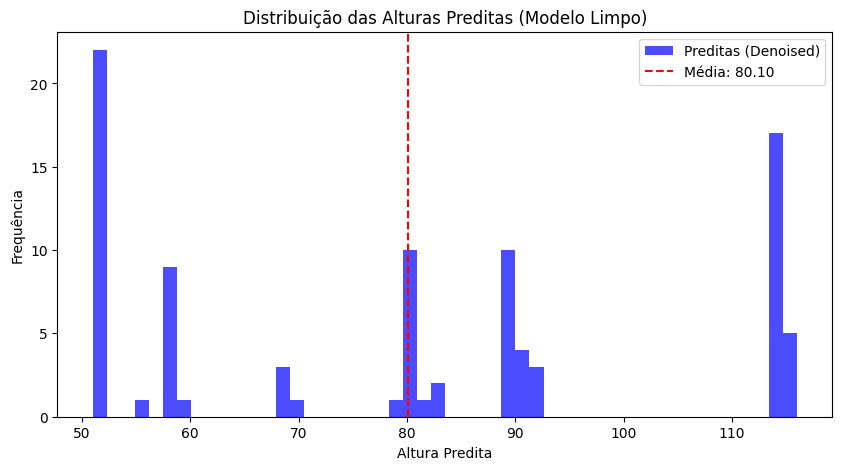

In [5]:
import matplotlib.pyplot as plt

# Distribuição das alturas preditas denoised
unique_pred, counts_pred = np.unique(predicted_heights_denoised, return_counts=True)

print(f'Alturas preditas únicas (denoised): {len(unique_pred)}')
print(f'Valores únicos e contagens:')
for h, c in zip(unique_pred, counts_pred):
    print(f'  {h}: {c}')

# Histograma
plt.figure(figsize=(10, 5))
plt.hist(predicted_heights_denoised, bins=50, alpha=0.7, color='blue', label='Preditas (Denoised)')
plt.axvline(np.mean(predicted_heights_denoised), color='red', linestyle='--', label=f'Média: {np.mean(predicted_heights_denoised):.2f}')
plt.xlabel('Altura Predita')
plt.ylabel('Frequência')
plt.title('Distribuição das Alturas Preditas (Modelo Limpo)')
plt.legend()
plt.show()

### Comparação Entrada vs Saída do Denoising Autoencoder

Analisamos as diferenças entre os dados de entrada (escalados) e saída (denoised) do autoencoder para avaliar o efeito do denoising.

Diferença média por canal (entrada vs saída):
  Canal 0: média 0.000005, std 0.000002
  Canal 1: média 0.000002, std 0.000001
  Canal 2: média 0.000000, std 0.000000
  Canal 3: média 0.000001, std 0.000001
  Canal 4: média 0.000002, std 0.000001
  Canal 5: média 0.000005, std 0.000002
  Canal 6: média 0.000003, std 0.000002
  Canal 7: média 0.000001, std 0.000001
  Canal 8: média 0.000000, std 0.000000
  Canal 9: média 0.000005, std 0.000001
  Canal 10: média 0.000002, std 0.000001
  Canal 11: média 0.000002, std 0.000001
  Canal 12: média 0.000000, std 0.000001
  Canal 13: média 0.000001, std 0.000000
  Canal 14: média 0.000004, std 0.000001
  Canal 15: média 0.000003, std 0.000002


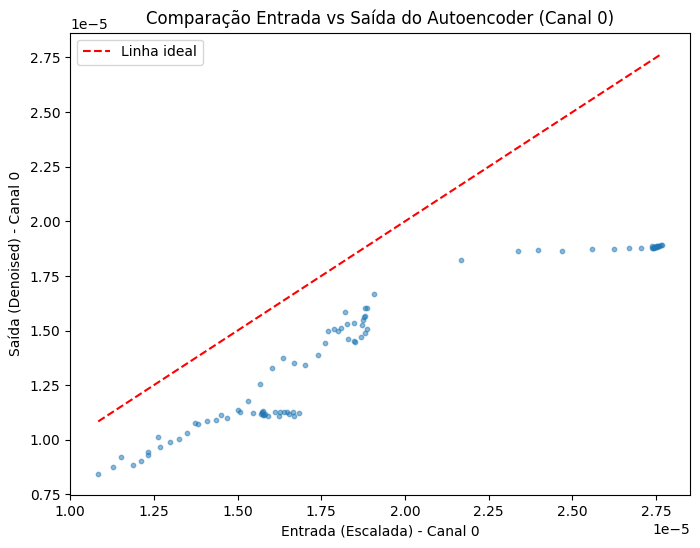

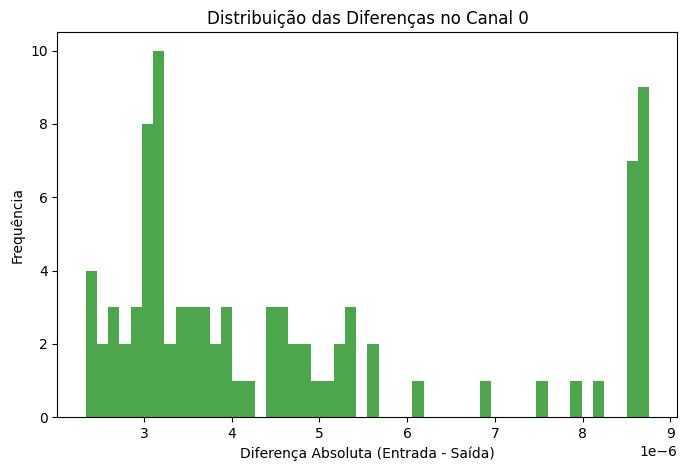

In [6]:
# Diferenças por canal (média absoluta)
differences = np.abs(features_scaled - features_denoised)
mean_diff_per_channel = np.mean(differences, axis=0)
std_diff_per_channel = np.std(differences, axis=0)

print(f'Diferença média por canal (entrada vs saída):')
for i, (md, sd) in enumerate(zip(mean_diff_per_channel, std_diff_per_channel)):
    print(f'  Canal {i}: média {md:.6f}, std {sd:.6f}')

# Scatter plot para um canal exemplo (canal 0)
plt.figure(figsize=(8, 6))
plt.scatter(features_scaled[:, 0], features_denoised[:, 0], alpha=0.5, s=10)
plt.plot([features_scaled[:, 0].min(), features_scaled[:, 0].max()], 
         [features_scaled[:, 0].min(), features_scaled[:, 0].max()], 'r--', label='Linha ideal')
plt.xlabel('Entrada (Escalada) - Canal 0')
plt.ylabel('Saída (Denoised) - Canal 0')
plt.title('Comparação Entrada vs Saída do Autoencoder (Canal 0)')
plt.legend()
plt.show()

# Histograma das diferenças para canal 0
plt.figure(figsize=(8, 5))
plt.hist(differences[:, 0], bins=50, alpha=0.7, color='green')
plt.xlabel('Diferença Absoluta (Entrada - Saída)')
plt.ylabel('Frequência')
plt.title('Distribuição das Diferenças no Canal 0')
plt.show()

## Etapa 4: Avaliação de Desempenho

Comparar o desempenho do KNN usando dados tratados pelo autoencoder vs. dados reais apenas escalados (sem denoising).

Alturas preditas únicas (denoised): 12
Valores únicos e contagens:
  57.0: 17
  62.0: 8
  63.0: 1
  67.0: 4
  68.0: 7
  80.0: 12
  82.0: 2
  88.0: 3
  91.0: 19
  93.0: 2
  95.0: 1
  97.0: 14


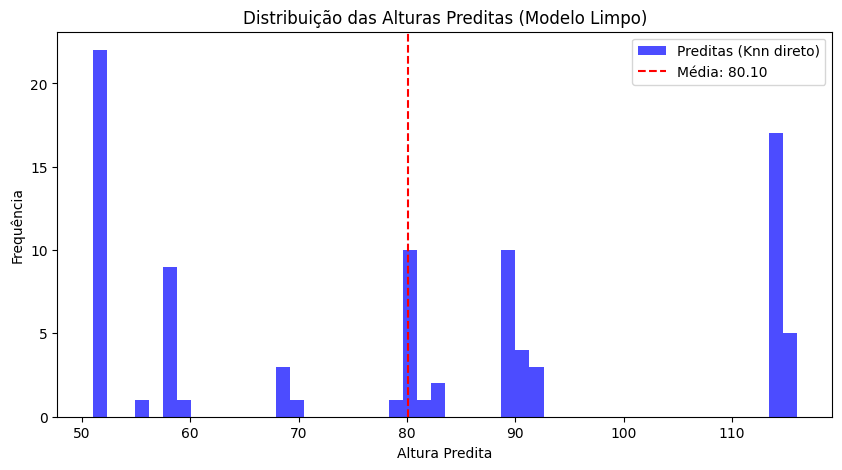

Métricas com dados apenas escalados - MAE: 7.0198, RMSE: 9.3916, R²: 0.8315

Comparação:
Melhoria MAE (denoised vs scaled): 2.1493
Melhoria RMSE (denoised vs scaled): 3.4293
Melhoria R² (denoised vs scaled): 0.1006
O denoising melhorou o desempenho do KNN!


In [ ]:
# Predizer com dados apenas escalados (sem denoising), mas aplicando o scaler do KNN
features_scaled_for_knn = scaler.transform(features_scaled)
predicted_heights_scaled = knn_model.predict(features_scaled_for_knn)

# Métricas para apenas escalados
mae_scaled = mean_absolute_error(heights, predicted_heights_scaled)
rmse_scaled = np.sqrt(mean_squared_error(heights, predicted_heights_scaled))
r2_scaled = r2_score(heights, predicted_heights_scaled)

import matplotlib.pyplot as plt

# Distribuição das alturas preditas denoised
unique_pred, counts_pred = np.unique(predicted_heights_scaled, return_counts=True)

print(f'Alturas preditas únicas (denoised): {len(unique_pred)}')
print(f'Valores únicos e contagens:')
for h, c in zip(unique_pred, counts_pred):
    print(f'  {h}: {c}')

# Histograma com comparação entre preditas e esperadas
plt.figure(figsize=(12, 6))
plt.hist(predicted_heights_denoised, bins=50, alpha=0.6, color='blue', label='Alturas Preditas (KNN)')
plt.hist(heights, bins=50, alpha=0.6, color='orange', label='Alturas Esperadas (Reais)')
plt.axvline(np.mean(predicted_heights_denoised), color='blue', linestyle='--', linewidth=2, label=f'Média Predita: {np.mean(predicted_heights_denoised):.2f}')
plt.axvline(np.mean(heights), color='orange', linestyle='--', linewidth=2, label=f'Média Esperada: {np.mean(heights):.2f}')
plt.xlabel('Altura')
plt.ylabel('Frequência')
plt.title('Comparação: Distribuição das Alturas Preditas vs Esperadas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Métricas com dados apenas escalados - MAE: {mae_scaled:.4f}, RMSE: {rmse_scaled:.4f}, R²: {r2_scaled:.4f}")

# Comparação
print("\nComparação:")
print(f"Melhoria MAE (denoised vs scaled): {mae_scaled - mae_denoised:.4f}")
print(f"Melhoria RMSE (denoised vs scaled): {rmse_scaled - rmse_denoised:.4f}")
print(f"Melhoria R² (denoised vs scaled): {r2_denoised - r2_scaled:.4f}")

if r2_denoised > r2_scaled:
    print("O denoising melhorou o desempenho do KNN!")
else:
    print("O denoising não melhorou significativamente o desempenho.")

## Conclusão

Este notebook demonstrou o pipeline completo. O denoising pode melhorar a precisão do KNN ao remover ruído dos dados experimentais. Ajuste os modelos e parâmetros conforme necessário para otimização.